### 1. Setup and Initialization
Importing the fundamental libraries required and mapping the reference file names with their respective values.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Set default figure size for matplotlib
plt.rcParams['figure.figsize'] = (10, 8)

# Dictionary mapping reference file names to their monetary float values
COIN_VALUES = {
    '1cent': 0.01,
    '2cent': 0.02,
    '5cent': 0.05,
    '10cent': 0.10,
    '20cent': 0.20,
    '50cent': 0.50,
    '1euro': 1.00,
    '2euro': 2.00
}

print("Libraries imported successfully and COIN_VALUES initialized.")

Libraries imported successfully and COIN_VALUES initialized.


### 2. Off-line Phase: Feature Extraction from Reference Models
Following the Local Invariant Features paradigm, we must first process our reference images to extract robust visual signatures. 

We utilize the **SIFT (Scale-Invariant Feature Transform)** algorithm. SIFT is chosen because it extracts local descriptors that are invariant to scale changes and robust to rotations (by assigning a Canonical Orientation to each keypoint). This is crucial, as the target coins may appear at different scales and orientations compared to our reference images. Simple intensity-based Template Matching (like SSD or ZNCC) would fail under these geometric variations.

Loaded     10cent:   75 keypoints extracted.
Loaded      1cent:  126 keypoints extracted.
Loaded      1euro:  201 keypoints extracted.
Loaded     20cent:  115 keypoints extracted.
Loaded      2cent:   60 keypoints extracted.
Loaded      2euro:  133 keypoints extracted.
Loaded     50cent:  118 keypoints extracted.
Loaded      5cent:  102 keypoints extracted.


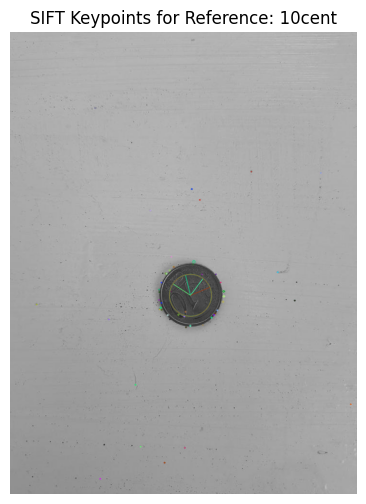

In [8]:
# Initialize the SIFT detector
sift = cv2.SIFT_create()

def build_reference_models(reference_dir):
    """
    Iterates through the reference images directory, extracts SIFT keypoints 
    and descriptors for each coin, and stores them in a dictionary.
    """
    reference_models = {}
    
    # Define valid image extensions
    valid_extensions = ('*.jpg', '*.jpeg', '*.png')
    filepaths = []
    for ext in valid_extensions:
        filepaths.extend(glob.glob(os.path.join(reference_dir, ext)))
        
    if not filepaths:
        print(f"No images found in {reference_dir}. Please check the path.")
        return reference_models
        
    for filepath in filepaths:
        filename = os.path.basename(filepath)
        # Extract the base name to use as dictionary key (e.g., '1_euro')
        coin_name = os.path.splitext(filename)[0]
        
        # Read the image in grayscale (SIFT operates on intensity gradients)
        img_gray = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        
        if img_gray is None:
            print(f"Warning: Could not read {filepath}")
            continue
            
        # Detect keypoints and compute descriptors
        keypoints, descriptors = sift.detectAndCompute(img_gray, None)
        
        # Store the extracted data
        reference_models[coin_name] = {
            'keypoints': keypoints,
            'descriptors': descriptors,
            'image': img_gray
        }
        
        print(f"Loaded {coin_name:>10}: {len(keypoints):>4} keypoints extracted.")
        
    return reference_models

# ==========================================
# VERIFICATION BLOCK
# ==========================================
REFERENCE_DIR = 'coin_dataset/reference_set' 

# Build the models
ref_models = build_reference_models(REFERENCE_DIR)

# Visually verify the extracted keypoints on one of the reference coins
if ref_models:
    # Pick the first coin loaded
    sample_coin = list(ref_models.keys())[0]
    
    # Draw keypoints with size and orientation (DRAW_RICH_KEYPOINTS)
    img_with_kp = cv2.drawKeypoints(
        ref_models[sample_coin]['image'], 
        ref_models[sample_coin]['keypoints'], 
        None, 
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_with_kp, cmap='gray')
    plt.title(f"SIFT Keypoints for Reference: {sample_coin}")
    plt.axis('off')
    plt.show()

### 3. On-line Phase: Coin Detection via Hough Transform
To locate the coins within the target images, we employ a geometric approach:
1. **Grayscale Conversion & Smoothing:** We convert the image to grayscale and apply a **Gaussian Filter**. As discussed in the theoretical material, differentiation (used in edge detection) inherently amplifies high-frequency noise. Smoothing is a mandatory pre-processing step to prevent spurious edges and false circle detections.
2. **Hough Circle Transform:** The Standard Hough Transform is explicitly designed to detect analytical shapes. By using the gradient-based Hough Circles method, we can robustly detect the centers and radii of the coins, even if they are partially occluded or affected by background clutter.

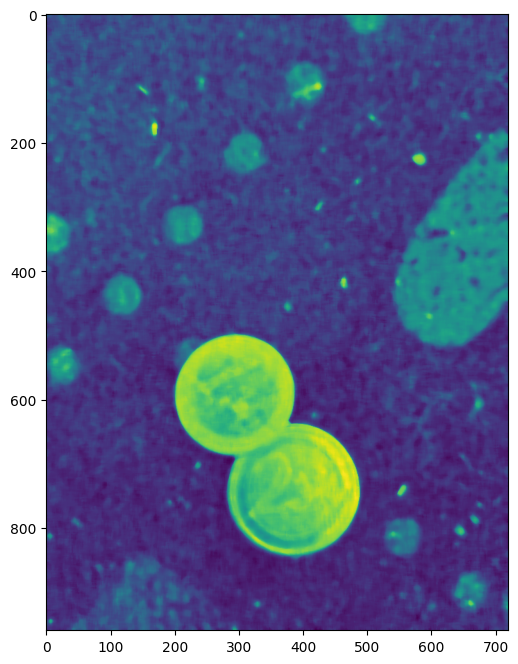

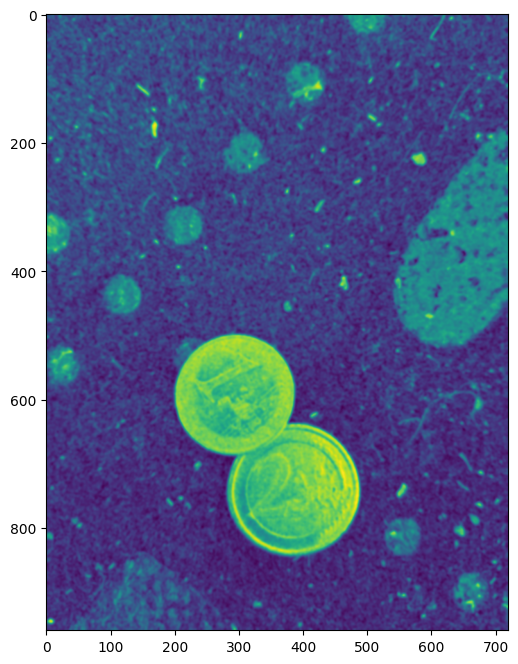

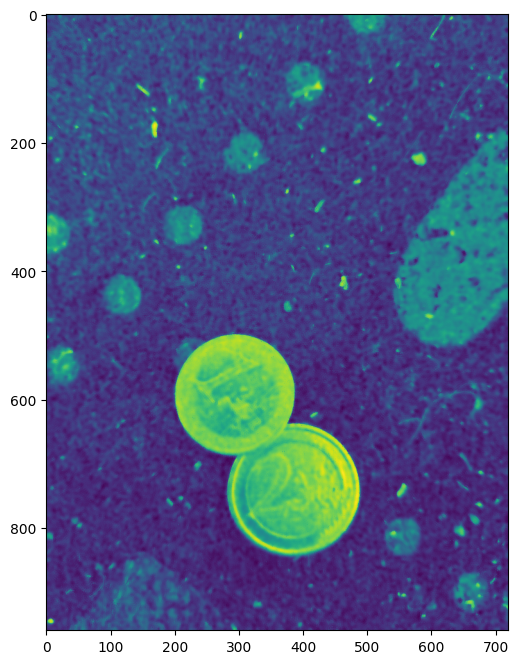

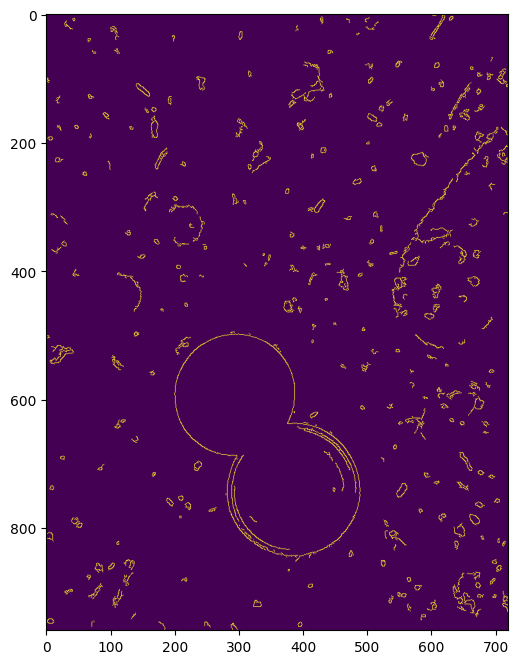

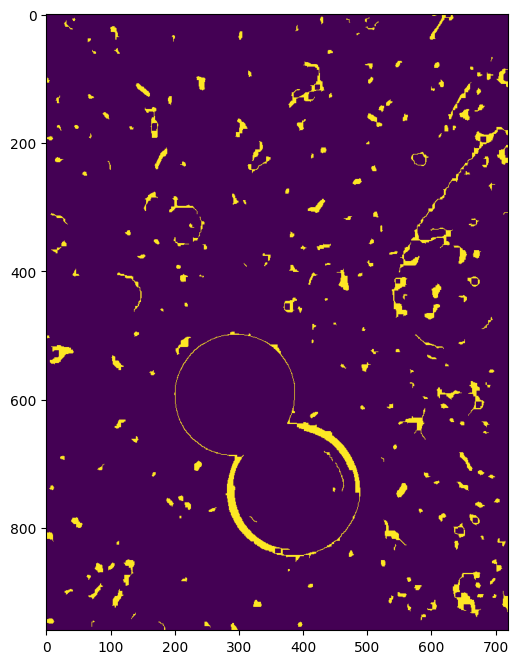

Detected 3 potential coins.


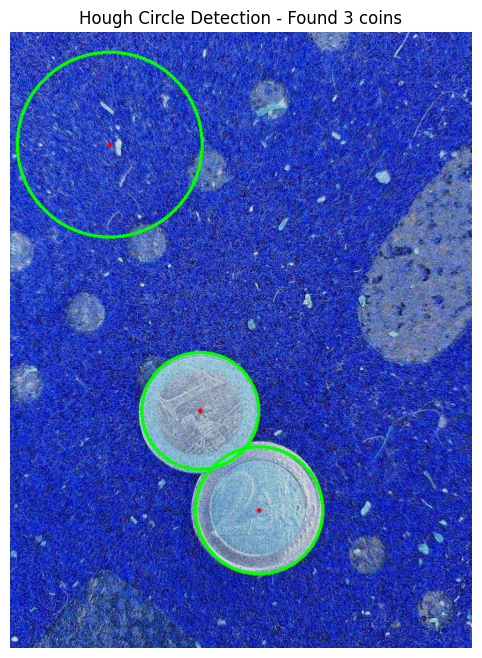

In [85]:
def detect_coins_hough(image_path, min_r=20, max_r=150):
    """
    Detects coins in a target image using the Hough Circle Transform.
    Returns the RGB image, the grayscale image, and a list of detected circles (x, y, radius).
    """
    # Load the image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not read the image at {image_path}")
        return None, None, []
        
    # Convert color spaces for processing and plotting
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Use Median Blur instead of Gaussian: it's better at removing salt-and-pepper 
    # noise while preserving edges, which helps Hough transform significantly 
    blurred = cv2.medianBlur(gray, 11)
    plt.figure(figsize=(10, 8))
    plt.imshow(blurred)
    plt.show()

    gaussian = cv2.GaussianBlur(gray, (9, 9), 0)
    plt.figure(figsize=(10, 8))
    plt.imshow(gaussian)
    plt.show()

    denoised = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    plt.figure(figsize=(10, 8))
    plt.imshow(denoised)
    plt.show()

    edges = cv2.Canny(denoised, 60, 150)
    plt.figure(figsize=(10, 8))
    plt.imshow(edges)
    plt.show()

    kernel = np.ones((7,7), np.uint8)
    closed = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel
    )
    plt.figure(figsize=(10, 8))
    plt.imshow(closed)
    plt.show()
    
    # Apply Hough Circle Transform
    # NOTE: dp, minDist, param1, and param2 are highly dependent on image resolution 
    # and might require fine-tuning based on the specific dataset provided.
    circles = cv2.HoughCircles(
        gaussian, 
        cv2.HOUGH_GRADIENT, 
        dp=1.2,           # Inverse ratio of accumulator resolution to image resolution
        minDist=70,       # Minimum distance between the centers of detected circles
        param1=75,        # Higher threshold for the internal Canny edge detector
        param2=60,        # Accumulator threshold for circle centers (lower = more false circles)
        minRadius=min_r,  # Minimum circle radius
        maxRadius=max_r   # Maximum circle radius
    )
    
    detected_circles = []
    if circles is not None:
        # Convert coordinates and radii to integers
        detected_circles = np.round(circles[0, :]).astype("int")
        print(f"Detected {len(detected_circles)} potential coins.")
    else:
        print("No coins detected. You may need to tune the HoughCircles parameters.")
        
    return img_rgb, gray, detected_circles

# ==========================================
# VERIFICATION BLOCK
# ==========================================
SAMPLE_TARGET_IMG = 'coin_dataset/target_set/image_44.jpg'

img_rgb, img_gray, circles = detect_coins_hough(SAMPLE_TARGET_IMG)

if img_rgb is not None and len(circles) > 0:
    # Make a copy to draw on
    output_img = img_rgb.copy()
    
    # Loop over the circles and draw them
    for (x, y, r) in circles:
        # Draw the outer circle (green)a
        cv2.circle(output_img, (x, y), r, (0, 255, 0), 4)
        # Draw the center point (red)
        cv2.circle(output_img, (x, y), 2, (255, 0, 0), 3)
        
    # Plot the result
    plt.figure(figsize=(10, 8))
    plt.imshow(output_img)
    plt.title(f"Hough Circle Detection - Found {len(circles)} coins")
    plt.axis('off')
    plt.show()

In [102]:
import cv2
import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# GROUND TRUTH — compila con i tuoi conteggi reali
# Formato: numero_immagine -> n_monete_reali
# ==========================================
GROUND_TRUTH_RAW = {
    1: 3, 2: 1, 3: 6, 4: 1, 5: 1,
    6: 1, 7: 3, 8: 1, 9: 1, 10: 1,
    11: 2, 12: 2, 13: 1, 14: 1, 15: 1,
    16: 2, 17: 3, 18: 3, 19: 1, 20: 3,
    21: 1, 22: 1, 23: 2, 24: 3, 25: 3,
    26: 2, 27: 5, 28: 2, 29: 1, 30: 3,
    31: 2, 32: 3, 33: 1, 34: 1, 35: 1,
    36: 2, 37: 3, 38: 7, 39: 2, 40: 5,
    41: 1, 42: 1, 43: 2, 44: 2, 45: 3,
    46: 3, 47: 3, 48: 1, 49: 3, 50: 2,
    51: 4, 52: 6, 53: 1, 54: 2, 55: 2,
    56: 1, 57: 3, 58: 3, 59: 2, 60: 1,
    61: 1, 62: 2, 63: 3, 64: 1, 65: 1,
    66: 3, 67: 2, 68: 1, 69: 1, 70: 1,
    71: 1, 72: 3, 73: 3, 74: 2, 75: 2,
    76: 4, 77: 3, 78: 3, 79: 5, 80: 2,
    81: 1, 82: 1, 83: 1, 84: 4, 85: 5,
    86: 3, 87: 1, 88: 6, 89: 2, 90: 2,
    91: 1, 92: 3, 93: 1, 94: 3, 95: 3,
    96: 8, 97: 4, 98: 4, 99: 1, 100: 1,
    101: 3, 102: 3, 103: 3, 104: 1, 105: 1,
    106: 3, 107: 1, 108: 1, 109: 2, 110: 2,
    111: 3, 112: 3, 113: 1, 114: 1, 115: 4,
    116: 1, 117: 1, 118: 8, 119: 1, 120: 2,
    121: 4, 122: 3, 123: 1, 124: 3, 125: 2,
    126: 3, 127: 2, 128: 3, 129: 1, 130: 2,
    131: 1, 132: 4, 133: 3, 134: 2, 135: 1,
    136: 2, 137: 3, 138: 3, 139: 2, 140: 2,
    141: 1, 142: 2,
}

HARD_CASES = {11, 24, 27, 32, 36, 40, 43, 55, 79, 85, 103, 132}

IMG_DIR = "coin_dataset/target_set"
IMG_TEMPLATE = "image_{}.jpg"   # ← adatta il formato del nome file se necessario

def img_path(n: int) -> str:
    return f"{IMG_DIR}/{IMG_TEMPLATE.format(n)}"

# Pre-carica e preprocessa tutte le immagini annotate (evita I/O ripetuto nei trial)
def preload_images(ground_truth: dict) -> dict:
    cache = {}
    for n,count in ground_truth.items():
        if count is None:          # ← salta le immagini non ancora annotate
            continue
        path = img_path(n)
        bgr = cv2.imread(path)
        
        if bgr is None:
            print(f"[WARN] Immagine non trovata: {path}")
            continue
        gray    = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        blurred = cv2.medianBlur(gray, 21)
        cache[n] = blurred
    print(f"[INFO] Caricate {len(cache)}/{len(ground_truth)} immagini.")
    return cache

# ==========================================
# FUNZIONE OBIETTIVO
# ==========================================
def evaluate_params(cache, ground_truth, dp, minDist, param1, param2, minR, maxR):
    """
    Ritorna l'errore totale (MAE) sul dataset annotato.
    Penalizza leggermente la sovrastima (falsi positivi).
    """
    if minR >= maxR:
        return float("inf")

    total_error = 0.0
    for n, blurred in cache.items():
        true_count = ground_truth[n]
        circles = cv2.HoughCircles(
            blurred,
            cv2.HOUGH_GRADIENT,
            dp=dp,
            minDist=minDist,
            param1=param1,
            param2=param2,
            minRadius=minR,
            maxRadius=maxR,
        )
        detected = int(len(circles[0])) if circles is not None else 0
        diff = detected - true_count
        # Sovrastima → penalità 1.5x, sottostima → 1x
        total_error += diff * 1.5 if diff > 0 else abs(diff)

    return total_error

# ==========================================
# OTTIMIZZAZIONE CON OPTUNA
# ==========================================
import random

def optimize(ground_truth: dict, n_trials: int = 300, sample_size: int = 20):
    cache = preload_images(ground_truth)
    if not cache:
        raise RuntimeError("Nessuna immagine caricata.")

    # Usa solo un campione casuale per velocizzare i trial
    sample_keys = random.sample(list(cache.keys()), min(sample_size, len(cache)))
    cache_sample = {k: cache[k] for k in sample_keys}
    gt_sample    = {k: ground_truth[k] for k in sample_keys}
    print(f"[INFO] Ottimizzazione su {len(cache_sample)} immagini campionate.")

    def objective(trial):
    # Campione diverso ad ogni trial
        remaining = [k for k in cache.keys() if k not in HARD_CASES]
        extra = random.sample(remaining, min(sample_size - len(HARD_CASES), len(remaining)))
        sample_keys = list(HARD_CASES) + extra
        cache_sample = {k: cache[k] for k in sample_keys if k in cache}
        gt_sample    = {k: ground_truth[k] for k in cache_sample}

        dp      = trial.suggest_float("dp",      1.0, 2.0, step=0.1)
        minDist = trial.suggest_int  ("minDist", 30,  150, step=10)
        param1  = trial.suggest_int  ("param1",  30,  120, step=5)
        param2  = trial.suggest_int  ("param2",  15,  70,  step=5)
        minR    = trial.suggest_int  ("minR",    10,  60,  step=5)
        maxR    = trial.suggest_int  ("maxR",    80,  200, step=10)
        return evaluate_params(cache_sample, gt_sample, dp, minDist, param1, param2, minR, maxR)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("\n" + "="*50)
    print(f"  Errore minimo : {study.best_value:.2f}")
    print(f"  Parametri ottimali:")
    for k, v in study.best_params.items():
        print(f"    {k:10s} = {v}")
    print("="*50)
    return study.best_params


# ==========================================
# DETECT CON PARAMETRI OTTIMIZZATI
# ==========================================
def detect_coins_hough(image_path, params: dict | None = None, min_r=20, max_r=150):
    p = params or {"dp":1.2, "minDist":70, "param1":65, "param2":35,
                   "minR":min_r, "maxR":max_r}

    bgr = cv2.imread(image_path)
    if bgr is None:
        print(f"[ERROR] Impossibile leggere: {image_path}")
        return None, None, []

    img_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray    = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 21)

    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT,
        dp=p["dp"], minDist=p["minDist"],
        param1=p["param1"], param2=p["param2"],
        minRadius=p["minR"], maxRadius=p["maxR"],
    )

    detected = []
    if circles is not None:
        detected = np.round(circles[0]).astype("int").tolist()
        print(f"[INFO] Rilevate {len(detected)} monete in {image_path}")
    else:
        print("[INFO] Nessuna moneta rilevata.")

    return img_rgb, gray, detected

# ==========================================
# MAIN
# ==========================================
if __name__ == "__main__":
    # Filtra solo le immagini effettivamente annotate
    annotated = {n: count for n, count in GROUND_TRUTH_RAW.items() if count is not None}

    if not annotated:
        print("[WARN] Nessuna immagine annotata — inserisci almeno un valore nel dizionario.")
        print("       Esempio: cambia  1: None  in  1: 5")
    else:
        print(f"[INFO] Immagini annotate: {len(annotated)}/142")
        best_params = optimize(annotated, n_trials=300)

        print("\n--- Inferenza su tutte le 142 immagini ---")
        for i in range(1, 143):
            path = img_path(i)
            _, _, coins = detect_coins_hough(path, params=best_params)

[INFO] Immagini annotate: 142/142
[INFO] Caricate 142/142 immagini.
[INFO] Ottimizzazione su 20 immagini campionate.


  0%|          | 0/300 [00:00<?, ?it/s]


  Errore minimo : 8.50
  Parametri ottimali:
    dp         = 1.5
    minDist    = 90
    param1     = 35
    param2     = 60
    minR       = 45
    maxR       = 170

--- Inferenza su tutte le 142 immagini ---
[INFO] Rilevate 3 monete in coin_dataset/target_set/image_1.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_2.jpg
[INFO] Rilevate 6 monete in coin_dataset/target_set/image_3.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_4.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_5.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_6.jpg
[INFO] Rilevate 3 monete in coin_dataset/target_set/image_7.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_8.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_9.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_10.jpg
[INFO] Rilevate 2 monete in coin_dataset/target_set/image_11.jpg
[INFO] Rilevate 1 monete in coin_dataset/target_set/image_12.jpg
[INFO] Rilevate 1

Detected: 0


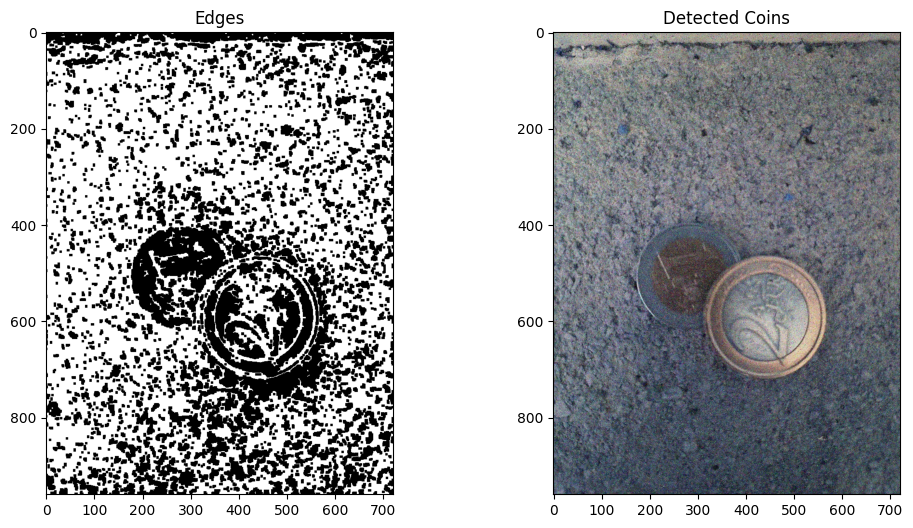

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_coins_edges(image_path):

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    gray = clahe.apply(gray)

    # Better than Gaussian for preserving edges
    filtered = cv2.bilateralFilter(
        gray,
        9,
        75,
        75
    )

    # Edge detection
    edges = cv2.Canny(filtered, 70, 150)

    # Close broken edges
    kernel = np.ones((5,5), np.uint8)
    edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    output = img_rgb.copy()

    detected = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area < 3000:
            continue

        perimeter = cv2.arcLength(cnt, True)

        if perimeter == 0:
            continue

        circularity = 4 * np.pi * area / (perimeter ** 2)

        # More permissive because overlap deforms contour
        if circularity > 0.35:

            (x, y), radius = cv2.minEnclosingCircle(cnt)

            x = int(x)
            y = int(y)
            radius = int(radius)

            # Radius filtering
            if 35 < radius < 90:

                detected.append((x, y, radius))

                cv2.circle(output, (x, y), radius, (0,255,0), 3)
                cv2.circle(output, (x, y), 2, (255,0,0), 3)

    return output, edges, detected


output, edges, detected = detect_coins_edges(
    'coin_dataset/target_set/image_55.jpg'
)

print("Detected:", len(detected))

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Detected Coins")

plt.show()

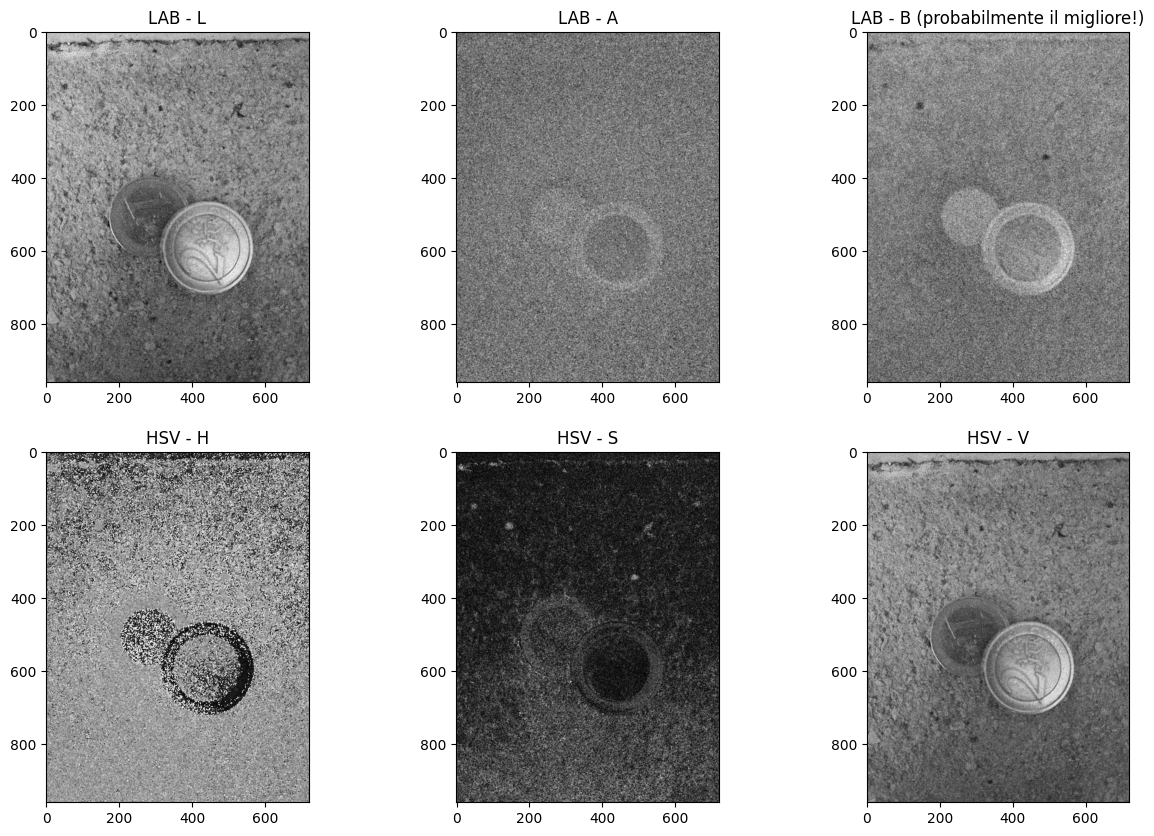

Detected 91 potential coins.


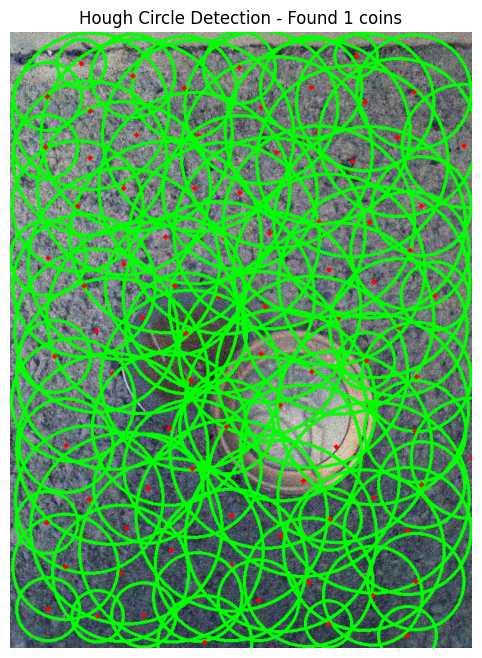

In [76]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Carica l'immagine originale (a colori!)
img = cv2.imread('coin_dataset/target_set/image_55.jpg') 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Converti in LAB
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

# Converti in HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Mostra i canali per decidere quale usare
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(l, cmap='gray'); axs[0, 0].set_title('LAB - L')
axs[0, 1].imshow(a, cmap='gray'); axs[0, 1].set_title('LAB - A')
axs[0, 2].imshow(b, cmap='gray'); axs[0, 2].set_title('LAB - B (probabilmente il migliore!)')
axs[1, 0].imshow(h, cmap='gray'); axs[1, 0].set_title('HSV - H')
axs[1, 1].imshow(s, cmap='gray'); axs[1, 1].set_title('HSV - S')
axs[1, 2].imshow(v, cmap='gray'); axs[1, 2].set_title('HSV - V')
plt.show()

circles = cv2.HoughCircles(
        b, 
        cv2.HOUGH_GRADIENT, 
        dp=1.2,           # Inverse ratio of accumulator resolution to image resolution
        minDist=70,       # Minimum distance between the centers of detected circles
        param1=75,        # Higher threshold for the internal Canny edge detector
        param2=70,        # Accumulator threshold for circle centers (lower = more false circles)
        minRadius=20,  # Minimum circle radius
        maxRadius=150   # Maximum circle radius
    )
    
detected_circles = []
if circles is not None:
    # Convert coordinates and radii to integers
    detected_circles = np.round(circles[0, :]).astype("int")
    print(f"Detected {len(detected_circles)} potential coins.")
else:
    print("No coins detected. You may need to tune the HoughCircles parameters.")
        
if img_rgb is not None and len(circles) > 0:
    # Make a copy to draw on
    output_img = img_rgb.copy()
    
    # Loop over the circles and draw them
    for (x, y, r) in detected_circles:
        # Draw the outer circle (green)a
        cv2.circle(output_img, (x, y), r, (0, 255, 0), 4)
        # Draw the center point (red)
        cv2.circle(output_img, (x, y), 2, (255, 0, 0), 3)
        
    # Plot the result
    plt.figure(figsize=(10, 8))
    plt.imshow(output_img)
    plt.title(f"Hough Circle Detection - Found {len(circles)} coins")
    plt.axis('off')
    plt.show()


Rilevate 2 monete.


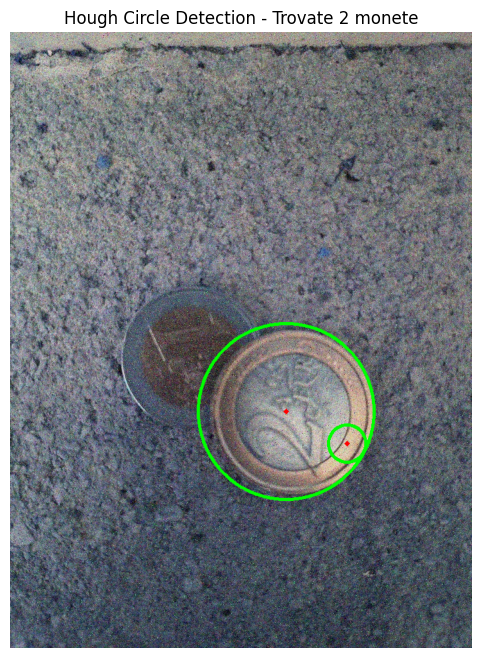

In [79]:
import cv2
import matplotlib.pyplot as plt
import numpy as np # IMPORTANTE

# Carica l'immagine
img = cv2.imread('coin_dataset/target_set/image_55.jpg') 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Converti in LAB e prendi il canale B
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

# PRE-PROCESSING: Fondamentale per HoughCircles
# Sfoca l'immagine per rimuovere il rumore e i dettagli inutili
b_blurred = cv2.GaussianBlur(b, (9, 9), 2)

# Esegui la trasformata
circles = cv2.HoughCircles(
    b_blurred, 
    cv2.HOUGH_GRADIENT, 
    dp=1.2, 
    minDist=70, 
    param1=50, 
    param2=10, # Spesso da abbassare se non trova nulla
    minRadius=20, 
    maxRadius=150 
)

# Gestione output
if circles is not None:
    # Converti in interi
    detected_circles = np.round(circles[0, :]).astype("int")
    print(f"Rilevate {len(detected_circles)} monete.")
    
    # Crea una copia per disegnare
    output_img = img_rgb.copy()
    
    # Itera sugli elementi dell'array (x, y, r)
    for (x, y, r) in detected_circles:
        # Disegna il cerchio esterno
        cv2.circle(output_img, (x, y), r, (0, 255, 0), 4)
        # Disegna il centro
        cv2.circle(output_img, (x, y), 2, (255, 0, 0), 3)
        
    plt.figure(figsize=(10, 8))
    plt.imshow(output_img)
    plt.title(f"Hough Circle Detection - Trovate {len(detected_circles)} monete")
    plt.axis('off')
    plt.show()
else:
    print("Nessuna moneta rilevata. Prova a regolare minDist, param1 o param2.")